In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)


verilerimizi inceleyelim

In [2]:
df = pd.read_csv("spam_ham_dataset.csv")
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [3]:
df.columns = df.columns.str.strip()
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB


en çok geçen kelimeleri inceleyelim ve silelim

C:\Users\tirek\AppData\Local\Temp\ipykernel_41508\3812327601.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='magma')


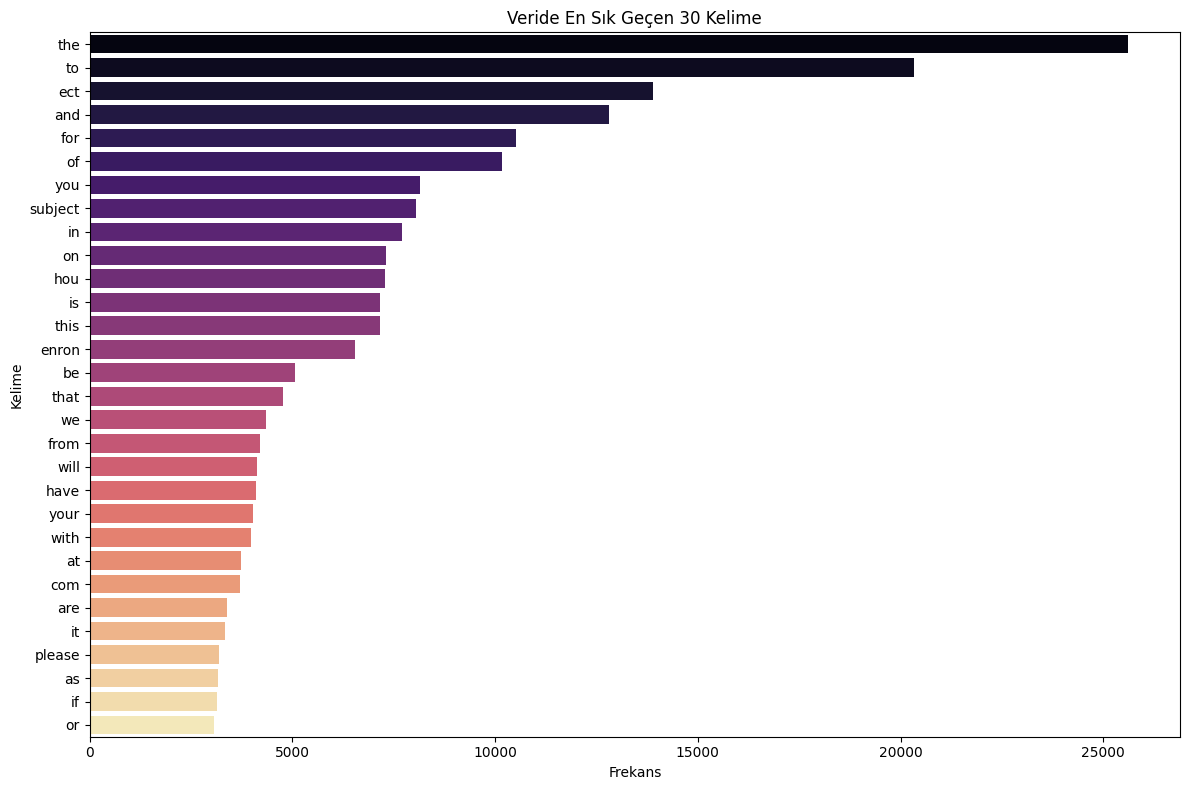

In [21]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Tüm metni birleştir
all_text = " ".join(df["text"].str.lower())

# Sadece harflerden oluşan (ve en az 2 harfli) kelimeleri al
tokens = re.findall(r'\b[a-z]{2,}\b', all_text)

# En sık geçen kelimeleri say
word_counts = Counter(tokens)
common_words = word_counts.most_common(30)

# Görselleştirme için ayrı listelere ayıralım
words, counts = zip(*common_words)

# Barplot çizimi
plt.figure(figsize=(12, 8))
sns.barplot(x=list(counts), y=list(words), palette='magma')
plt.title("Veride En Sık Geçen 30 Kelime")
plt.xlabel("Frekans")
plt.ylabel("Kelime")
plt.tight_layout()
plt.show()

# En sık geçen kelimeleri bir listeye alalım
common_words_list = [word for word, _ in common_words]

# Verilerimizden bu kelimeleri çıkaralım
def remove_common_words(text, common_words_list):
    words = text.split()
    filtered_words = [word for word in words if word not in common_words_list]
    return " ".join(filtered_words)

# DataFrame'deki metni temizleyelim
df['cleaned_text'] = df['text'].apply(lambda x: remove_common_words(x.lower(), common_words_list))



şimdi stop wordleri çıkaralım

In [23]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Scikit-learn stopword'lerini çıkaralım
def remove_sklearn_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(filtered_words)

# 'cleaned_text' üzerinden stopword'leri çıkaralım
df['final_cleaned_text'] = df['cleaned_text'].apply(lambda x: remove_sklearn_stopwords(x))


şimdi en çok geçen kelimeleri tekrardan kontrol edelim

C:\Users\tirek\AppData\Local\Temp\ipykernel_41508\2382331579.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='magma')


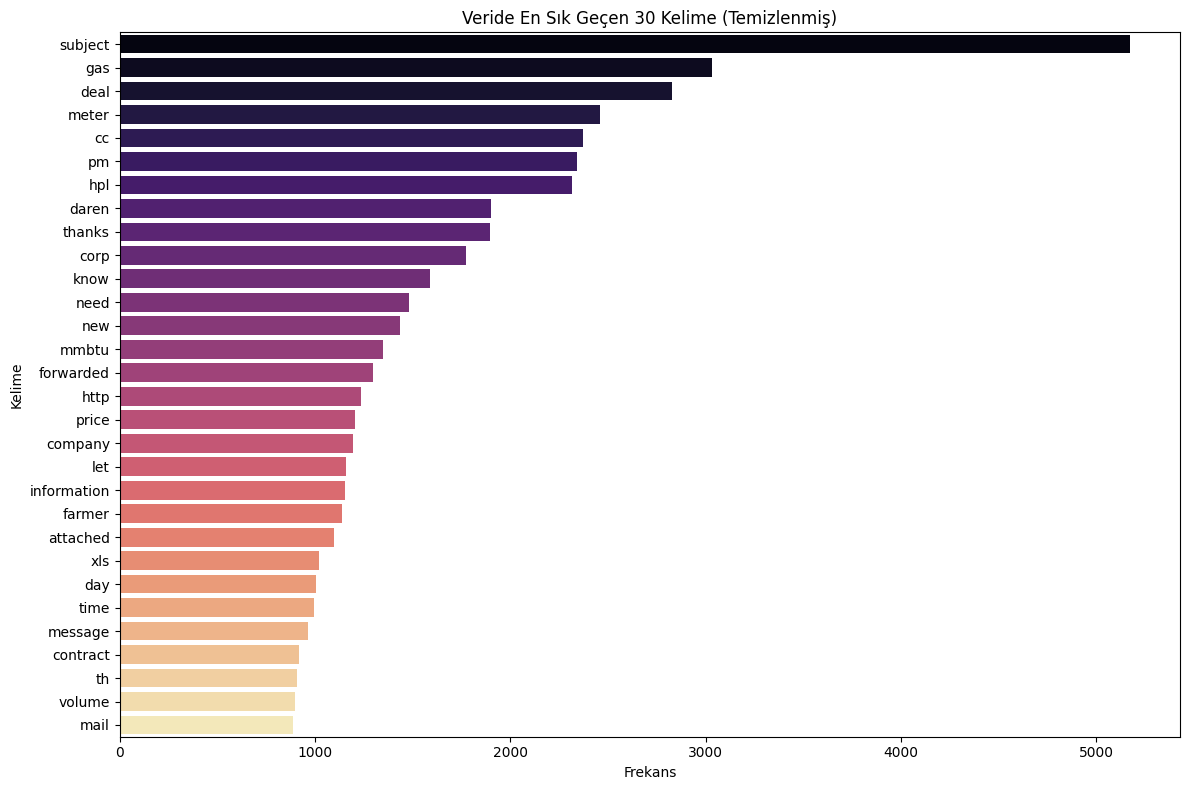

In [24]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Tüm metni birleştir
all_cleaned_text = " ".join(df["final_cleaned_text"].str.lower())

# Sadece harflerden oluşan (ve en az 2 harfli) kelimeleri al
tokens = re.findall(r'\b[a-z]{2,}\b', all_cleaned_text)

# En sık geçen kelimeleri say
word_counts = Counter(tokens)
common_words = word_counts.most_common(30)

# Görselleştirme için ayrı listelere ayıralım
words, counts = zip(*common_words)

# Barplot çizimi
plt.figure(figsize=(12, 8))
sns.barplot(x=list(counts), y=list(words), palette='magma')
plt.title("Veride En Sık Geçen 30 Kelime (Temizlenmiş)")
plt.xlabel("Frekans")
plt.ylabel("Kelime")
plt.tight_layout()
plt.show()


Doğruluk Skoru: 0.9758454106280193
Sınıflandırma Raporu:
               precision    recall  f1-score   support

         ham       0.98      0.98      0.98       742
        spam       0.96      0.96      0.96       293

    accuracy                           0.98      1035
   macro avg       0.97      0.97      0.97      1035
weighted avg       0.98      0.98      0.98      1035



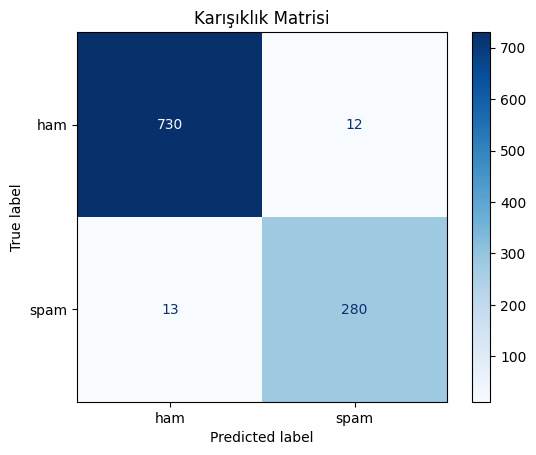

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# X ve y olarak ayıralım
X = df['final_cleaned_text']  # Özellikler (temizlenmiş metin)
y = df['label']  # Hedef değişken (etiketler)

# Veriyi eğitim ve test setlerine bölelim
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Metni sayısal verilere dönüştürmek için TfidfVectorizer kullanacağız
vectorizer = TfidfVectorizer(max_features=5000)  # 5000 özellik alalım, ihtiyaca göre ayarlanabilir
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# KNN modelini oluşturuyoruz
knn = KNeighborsClassifier(n_neighbors=5 ,metric="cosine", weights="distance")  # K değeri 5 olarak belirledik
knn.fit(X_train_tfidf, y_train)

# Test seti ile tahmin yapalım
y_pred = knn.predict(X_test_tfidf)

# Sonuçları değerlendirelim
print("Doğruluk Skoru:", accuracy_score(y_test, y_pred))
print("Sınıflandırma Raporu:\n", classification_report(y_test, y_pred))

# Karışıklık matrisini oluşturalım
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
cm_display.plot(cmap=plt.cm.Blues)
plt.title("Karışıklık Matrisi")
plt.show()


C:\Users\tirek\AppData\Local\Temp\ipykernel_41508\974395837.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette='viridis')


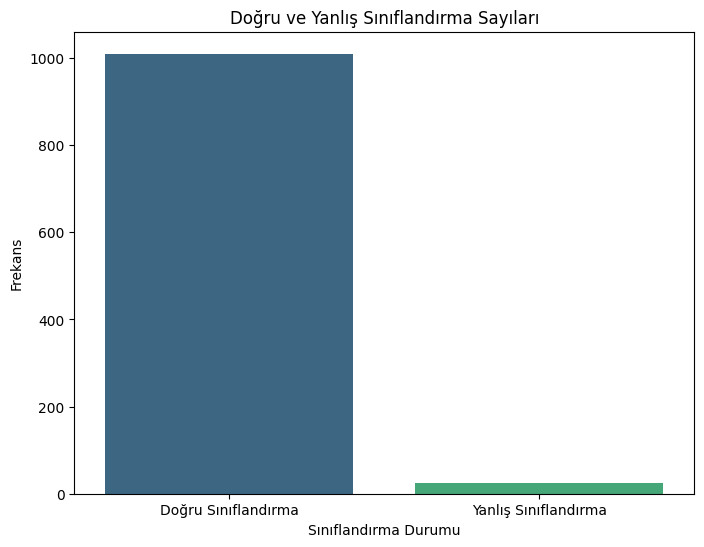

In [41]:
import numpy as np

# Doğru ve yanlış sınıflandırmalar
correct = np.sum(y_pred == y_test)
incorrect = np.sum(y_pred != y_test)

# Verileri barplot için hazırlayalım
labels = ['Doğru Sınıflandırma', 'Yanlış Sınıflandırma']
values = [correct, incorrect]

# Barplot çizimi
plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=values, palette='viridis')
plt.title("Doğru ve Yanlış Sınıflandırma Sayıları")
plt.xlabel("Sınıflandırma Durumu")
plt.ylabel("Frekans")
plt.show()


In [42]:
# Örnek bir metin verisi
new_text = "This is an example text to test the model. It contains words that need to be classified."

# 1. Metni temizleyelim (bunu daha önce yaptık, burada aynı işlemi tekrarlıyoruz)
new_text_cleaned = remove_sklearn_stopwords(new_text.lower())  # Eğer stopword'ler çıkarılmışsa

# 2. Metni sayısal verilere dönüştürelim (TfidfVectorizer ile)
new_text_tfidf = vectorizer.transform([new_text_cleaned])

# 3. Modeli kullanarak tahmin yapalım
predicted_label = knn.predict(new_text_tfidf)

# 4. Tahmin edilen sınıfı yazdıralım
print("Tahmin Edilen Etiket:", predicted_label[0])



Tahmin Edilen Etiket: spam
